In [1]:
import numpy as np
import pandas as pd
import glob
import os
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.io import ascii
from astropy.table import Table
import itertools
from itertools import chain
from astroquery.simbad import Simbad
from utils import PLOT_PARAMS
from astropy import constants as const
from matplotlib import colors
PLOT_PARAMS()
import thejoker as tj
import random
random.seed(42) 
from astropy.time import Time
from datetime import datetime

from astropy.coordinates import EarthLocation
from scipy.optimize import newton
import thejoker as tj
import pymc as pm
import corner
import arviz as az

from datetime import date
today=date.today()
DATE =today.strftime("%m_%d_%y")
print(DATE)
import pickle
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

plt.rcParams['figure.facecolor'] = 'white'
import warnings
warnings.filterwarnings("ignore")
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
import astropy.units as u

vlt = EarthLocation.of_site('paranal')  # the easiest way... but requires internet

09_21_26


In [2]:
galah_pd = (Table.read('../../lithium/data/GALAH_DR3_main_allstar_v2.fits',format='fits')).to_pandas()

In [3]:
galah_vac = Table.read('../../lithium/data/GALAH_DR3_VAC_ages_v2.fits').to_pandas()


In [4]:
rv_df = pd.read_csv('rv_df_new.csv')

In [5]:
comb_df = pd.read_csv('combined_rvs_new.csv')


In [6]:
binary_list_113 = [9, 11, 16, 18, 19, 23,] # old: 1, 4, 5, 7, 9, 11, 16, 18, 19, 21, 23  
binary_list_112 = [6, 7, 23] #old: 5, 6, 7, 23 #13 removed because of dipper star
binary_list_116 = [17] 


In [7]:
print('dr2',galah_pd[galah_pd.sobject_id==170514002101318]['dr2_source_id'].values[0])
rv_df[(rv_df.RG_id==23) & (rv_df.program==112)][['sobject_id','dr3_source_id']]

# 6673373227923805312

dr2 5232071641786703872


,sobject_id,dr3_source_id
7,170514002101318,5232071641786703488


In [8]:
# comb_df

In [9]:
def func1(logg):
    a, b = -0.60, 3.31
    log_v = a*logg+b
    return 10.**log_v
    
def func2(logg):
    siga, sigb = 0.04, 0.10
    a, b = -0.60, 3.31
    a = a+3.5*siga
    b = b+3.5*sigb
    log_v = (a*logg+b)
    return 10.**log_v
    
def func3(logg):
    siga, sigb = -0.04, -0.10
    a, b = -0.60, 3.31
    a = a+3.5*siga
    b = b+3.5*sigb
    log_v = (a*logg+b)
    return 10.**log_v
    
def func_2sigma(logg):
    siga, sigb = 0.04, 0.10
    a, b = -0.60, 3.31
    a = a+2*siga
    b = b+2*sigb
    log_v = (a*logg+b)
    return 10.**log_v
    
def func4(logg):
    siga, sigb = 0.04, 0.10
    a, b = -0.60, 3.31
    a = a+1.5*siga
    b = b+1.5*sigb
    log_v = (a*logg+b)
    return 10.**log_v
    
                

In [10]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors



In [133]:
def clean_up(df,source):
    galah_id = df.sobject_id.values[0]
    dtemp    = comb_df[(comb_df.GALAH_ID==galah_id) & (comb_df.source==source)]

    time = dtemp['time'].to_numpy()
    rv   = dtemp['rv'].to_numpy()
    err  = dtemp['rv_err'].to_numpy()
    source  = dtemp['source'].to_numpy()
    
    
    return time, rv, err, source, dtemp

x = clean_up(rv_df[(rv_df.RG_id==6) & (rv_df.program==112)],source='ESPRESSO')
y = clean_up(rv_df[(rv_df.RG_id==7) & (rv_df.program==112)],source='ESPRESSO')
z = clean_up(rv_df[(rv_df.RG_id==23) & (rv_df.program==112)],source='ESPRESSO')

print(np.min(x[0]))
target_time = Time(np.min(x[0]), format="jd", scale="tcb")
print(target_time.to_datetime().year,target_time.to_datetime().month)

target_time = Time(np.min(y[0]), format="jd", scale="tcb")
print(target_time.to_datetime().year,target_time.to_datetime().month)

target_time = Time(np.min(z[0]), format="jd", scale="tcb")
print(target_time.to_datetime().year,target_time.to_datetime().month)

for i in binary_list_113:
    x = clean_up(rv_df[(rv_df.RG_id==i) & (rv_df.program==113)],source='ESPRESSO')
    target_time = Time(np.min(x[0]), format="jd", scale="tcb")
    print(target_time.to_datetime().year,target_time.to_datetime().month)
    
from datetime import datetime

start_time = datetime(2023, 11, 1, 10, 0, 0)
end_time = datetime(2028, 4, 1, 0, 0, 0)

# Calculate duration
duration = end_time - start_time
print(duration.days/365)

2460252.50466007
2023 11
2023 11
2024 2
2024 5
2024 5
2024 4
2024 5
2024 5
2024 5
4.416438356164384


161013005401317 3142806554658429952
161104004801189 2945063305416392192
# of binary candidates to follow-up: 10
# to confirm binarity: 14
RV range of confirmation cand.: 0.14813531340374908 1.0353505110624894


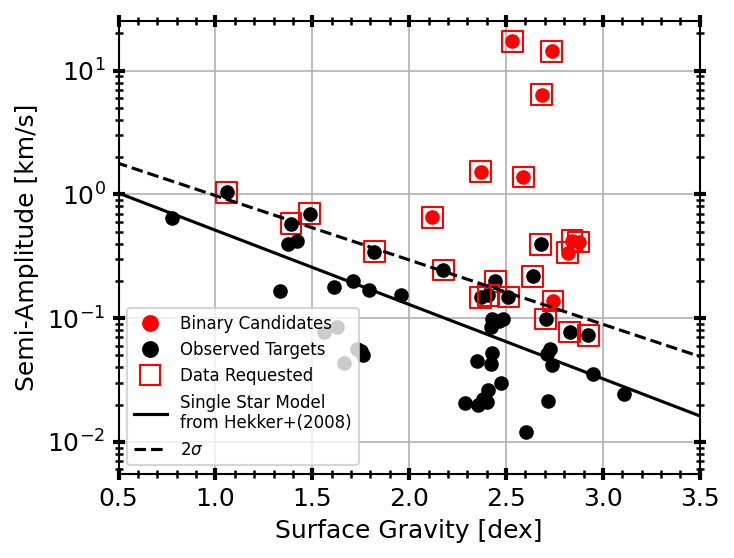

In [135]:
PLOT_PARAMS(LS=12, SIZE=12)
def make_semiK_plot():
    plt.figure(figsize=(5,4),dpi=150)
    ax=plt.subplot(111)
    follow_up_id     = []
    proposed_star_id = []
    proposed_star_rv = []
    
    for i, row in rv_df.iterrows():
        _, rv, _, _, _ = clean_up(rv_df[(rv_df.RG_id==row.RG_id) & (rv_df.program==row.program)],source='ESPRESSO')
        semiK = (max(rv) - min(rv))/2.
#         if (row.logg < 2.5) & (row.logg>2.3) & (semiK > 0.1) & (semiK < 0.2):
#             plt.scatter(row.logg, semiK,c='C1',marker='*',s=200)
        if row.program==112:
            if row.RG_id in binary_list_112:
                plt.scatter(row.logg, semiK,c='r')
                plt.scatter(row.logg, semiK,ec='r', marker='s',s=100, fc='None')
                follow_up_id.append(row.sobject_id)
            elif semiK > (func4(row.logg)/1000.) :#and row.logg<2.:
                plt.scatter(row.logg, semiK,ec='r', marker='s',s=100, fc='None')
                plt.scatter(row.logg, semiK,c='k')
                proposed_star_id.append(row.sobject_id)
                proposed_star_rv.append(semiK)
                print(row.sobject_id, row.dr3_source_id)
            else:
                plt.scatter(row.logg, semiK,c='k')
                
        if row.program==113:
            if row.RG_id in binary_list_113:
                plt.scatter(row.logg, semiK,c='r')
                plt.scatter(row.logg, semiK,ec='r', marker='s',s=100, fc='None')
                follow_up_id.append(row.sobject_id)
            elif semiK > (func4(row.logg)/1000.) :#and row.logg<2.:
                plt.scatter(row.logg, semiK,ec='r', marker='s',s=100, fc='None')
                plt.scatter(row.logg, semiK,c='k')
                proposed_star_id.append(row.sobject_id)
                proposed_star_rv.append(semiK)
            else:
                plt.scatter(row.logg, semiK,c='k')
                
        if row.program==116:
            if row.RG_id in binary_list_116:
                plt.scatter(row.logg, semiK,c='r')
                plt.scatter(row.logg, semiK,ec='r', marker='s',s=100, fc='None')
                follow_up_id.append(row.sobject_id)
            elif semiK > (func4(row.logg)/1000.) :#and row.logg<2.:
                plt.scatter(row.logg, semiK,ec='r', marker='s',s=100, fc='None')
                plt.scatter(row.logg, semiK,c='k')
                proposed_star_id.append(row.sobject_id)
                proposed_star_rv.append(semiK)
            else:
                plt.scatter(row.logg, semiK,c='k')
    
    
    for i, row in rv_df.iterrows():
        _, rv, _, _, _ = clean_up(rv_df[(rv_df.RG_id==row.RG_id) & (rv_df.program==row.program)],source='ESPRESSO')
        semiK = (max(rv) - min(rv))/2.
        star_id = row.sobject_id
        
        if (star_id in follow_up_id) or (star_id in proposed_star_id): 
            continue

        if (row.logg < 2.5) & (row.logg>2.3) & (semiK > 0.1) & (semiK < 0.2):
            #plt.scatter(row.logg, semiK,c='C1',marker='*',s=200)
            plt.scatter(row.logg, semiK,ec='r', marker='s',s=100, fc='None')
            proposed_star_id.append(star_id)
        if (row.logg < 2.8) & (row.logg>2.6) & (semiK > 0.09) & (semiK < 0.2):
            #plt.scatter(row.logg, semiK,c='green',marker='*',s=200)
            plt.scatter(row.logg, semiK,ec='r', marker='s',s=100, fc='None')
            proposed_star_id.append(star_id)
        if (row.logg < 3.0) & (row.logg>2.8) & (semiK > 0.07) & (semiK < 0.2):
            #plt.scatter(row.logg, semiK,c='purple',marker='*',s=200)
            plt.scatter(row.logg, semiK,ec='r', marker='s',s=100, fc='None')
            proposed_star_id.append(star_id)
    
    print('# of binary candidates to follow-up:',len(follow_up_id))
    print('# to confirm binarity:',len(proposed_star_id))
    print('RV range of confirmation cand.:',min(proposed_star_rv),max(proposed_star_rv))
    x = np.linspace(0.,4, 100)
    y1 = func1(x)/1000.
    y2 = func2(x)/1000.
    y3 = func3(x)/1000.
    y4 = func_2sigma(x)/1000.
    plt.plot(x,y1, c='k')
    #plt.plot(x,y2, c='k',ls='dotted',label=r'3.5$\sigma$')
    plt.plot(x,y4, c='k',ls='dashed')
    plt.legend()
    plt.xlim(0.5,3.5)
#     plt.axvspan(2.0,3.0, color='green',alpha=0.2,zorder=0)
    plt.yscale('log')
    plt.xlabel('Surface Gravity [dex]')
    plt.ylabel('Semi-Amplitude [km/s]')
    plt.grid()
    
    '''plt.annotate('Follow-up requested',  # The text to display
                xy=(1.5, 1),  # The point the arrow points to (x, y coordinates)
                xytext=(1.5, 10),  # The position of the text (x, y coordinates)
                arrowprops=dict(color='r', width=2.,headwidth=10),  # Properties of the arrow
                fontsize=10,
                color='r',ha='center'
            )
    '''
    
    lgnd = [Line2D([0], [0], marker='o', mec='r',mfc='r',ms=np.sqrt(50),ls='',label='Binary Candidates'), 
            Line2D([0], [0], marker='o', mec='k',mfc='k',ms=np.sqrt(50),ls='',label='Observed Targets'), 
            Line2D([0], [0], marker='s', mec='r',mfc='None',ms=np.sqrt(100),ls='',label='Data Requested'), 
#             Line2D([0], [0], marker='s', mec='r',mfc='None',ms=np.sqrt(100),ls='',label='Follow-up Requested'), 
            Line2D([0], [0], mec='k',c='k',ls='solid',label='Single Star Model\nfrom Hekker+(2008)'),
#             Line2D([0], [0], c='k',ls='dotted',label='3.5$\sigma$'),
            Line2D([0], [0], c='k',ls='dashed',label='2$\sigma$')
           ]
    ax.legend(handles=lgnd,fontsize=8)
    return follow_up_id, proposed_star_id
#     ,label='',,label=''
follow_up_sample, more_sample = make_semiK_plot()
# plt.savefig('../p118_proposal/p118_semiK.png',bbox_inches='tight',dpi=200)


In [148]:
proposed_sample = np.concatenate([follow_up_sample, more_sample])
len(proposed_sample)
proposed_sample = galah_pd[galah_pd.sobject_id.isin(proposed_sample)]
def get_formatted_table(final_df):
    final_id  = []
    final_ra  = []
    final_dec = []
    final_mag = []
    sobject_id = []
    for i,row in final_df.iterrows():
        gaia_id = row.dr2_source_id
        ra      = row.ra_dr2
        dec     = row.dec_dr2
        vmag    = row.v_jk
        sid     = row.sobject_id

        c  = SkyCoord(ra, dec, frame='icrs', unit='deg')
        ra = c.ra.to_string(u.hour,sep=":", precision=2)
        c_new = c.to_string(style='hmsdms',precision=2)
        ra, dec = c_new.split(' ')
        ra= ra.replace('h',':')
        ra=ra.replace('m',':')
        ra=ra.replace('s','')
        dec=dec.replace('d',':')
        dec=dec.replace('m',':')
        dec=dec.replace('s','')
        sobject_id.append(sid)

        #dec = c.dec.to_string(u.degree, alwayssign=True,sep=":", precision=1)
    #     sobject_id.append(row.sobject_id)
        final_ra.append(ra)
        final_dec.append(dec)
        final_mag.append('(V=%.1f)'%vmag)
        final_id.append(gaia_id)
    data = {'sid':sobject_id,'Name':final_id,'RA':final_ra,'Dec':final_dec,'Mag':final_mag}
    data = pd.DataFrame(data)
    return data
proposed_sample_table = get_formatted_table(proposed_sample)
proposed_sample_table.to_csv('p118_proposal_sample.csv',index=False)

In [13]:
# 161013005401317 3142806554658429952
# 161104004801189 2945063305416392192
star = 161104004801189
print('dr2',galah_pd[galah_pd.sobject_id==star]['dr2_source_id'].values[0])
print('dr3',rv_df[(rv_df.sobject_id==star)].dr3_source_id.values[0])



dr2 2945063305416392192
dr3 2945063305416392192


In [14]:

# Example: Observer at Mauna Kea Observatory
vlt_location = EarthLocation.of_site('paranal')  # the easiest way... but requires internet

location = EarthLocation.from_geodetic(lon=vlt_location.lon, lat=vlt_location.lat, height=vlt_location.height)


In [121]:

# Example datetime object
p118_start = datetime(2027, 5, 1, 12, 0, 0)
p118_end   = datetime(2028, 4, 30, 12, 0, 0)

# Convert to astropy Time object, specifying the scale (e.g., UTC)
tstart = Time(p118_start, scale='utc')
tend   = Time(p118_end, scale='utc')

tstart = Time(p118_start, scale='utc', location=location)
tend   = Time(p118_end, scale='utc', location=location)

# 4. Calculate the Barycentric Julian Date (BJD)
# bjd = t.bjd
print(tstart.mjd)
print(tend.mjd)

# Calculate BJD, specifying the observer's location
# bjd_start = tstart.light_travel_time(location).jd  # This calculates BJD_TDB
# bjd_end   = tend.light_travel_time(location).jd  # This calculates BJD_TDB



61526.5
61891.5
60303.348536210135


(2023, 12)

In [16]:
dftemp  = rv_df[(rv_df.RG_id==23) & (rv_df.program==112)]

# galah_vac[galah_vac.sobject_id==170514002101318].m_act_bstep


In [17]:
def convert_mjd_to_jd(mjd):
    t = Time(mjd, format='mjd', scale='local')
    return t.mjd

version = 1

In [18]:
p118_start_mjd = tstart.mjd#61161.5
p118_end_mjd   = tend.mjd#61525.5


In [19]:
PLOT_PARAMS(SIZE=10,LS=10)
def kepler_eq(E, M, e):
    return E - e * np.sin(E) - M

def get_vr(time_grid, t0, K, omega, M0, P, e, v0):
    # omega: argument of periastron (rad)
    
    # Compute RV curve
    vr = []
    
    # use first time step to find phi0
    
    phi0 = 2*np.pi*t0/P - M0
    
    for i,ti in enumerate(time_grid):
        if i == 0:
            E = newton(kepler_eq, M0, args=(M0, e))
            nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                                np.sqrt(1 - e) * np.cos(E / 2))
            v = K * (np.cos(nu + omega) + e * np.cos(omega))

        else:
            M = 2 * np.pi * ti / P - phi0
            E = newton(kepler_eq, M, args=(M, e))
            nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                                np.sqrt(1 - e) * np.cos(E / 2))
            v = K * (np.cos(nu + omega) + e * np.cos(omega))
        vr.append(v)

    vr_kms = np.array(vr)
    vr     = vr_kms  + v0
    
    return vr


[60455.3159034499, 60473.357035030145, 60489.37269491982, 60506.086685420014, 60526.128989240155]
[14.5815151308206, 14.9710373837021, 15.4856280741578, 16.290014447224, 17.34191932688]
4 5
1 30


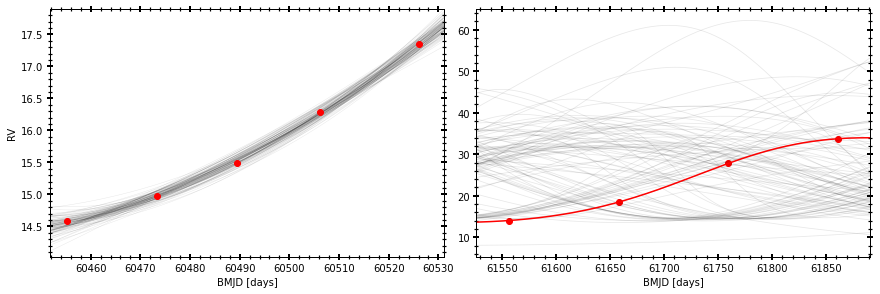

In [20]:

def plot_one_star(program, obj, choice=1, time=False, rv=False, N=1, ylim=False,xlim=False,n_sample=5):
    
#     if time is False:
    target_time, target_rv, _, _, _ = clean_up(rv_df[(rv_df.RG_id==obj) & (rv_df.program==program)], source='ESPRESSO')
    idx = np.argsort(target_time)
    target_time, target_rv = target_time[idx], target_rv[idx]

    t0 = min(target_time)
    
    data = Table()
    data["bjd"]     = target_time
    data["rv"]      = target_rv
    target_time = Time(data["bjd"], format="jd", scale="tcb")

    fname   = '../joker_samples/%s_%s_joker_%s.hdf5'%(program,obj,version)
    joker_samples = tj.JokerSamples.read(fname)
    
    fig = plt.figure(figsize=(12,4))
    ax1 = plt.subplot(121)
    ax2 = plt.subplot(122)
    print(list(target_time.mjd))
    print(list(target_rv))
    current_time = np.linspace(min(target_time.mjd)-100, max(target_time.mjd)+100, 10000)
    future_time  = np.linspace(p118_start_mjd-2, p118_end_mjd+2, 10000)
    
    t1 = Time(current_time, format="mjd", scale="tcb")
    t2 = Time(future_time, format="mjd", scale="tcb")

    n_plot = n_sample
    Q = 4.0  # HACK
    line_alpha = 0.05 + Q / (n_plot + Q)
    
    all_future_orbits = []
    
    for n_sample in range(n_sample):
        current_orbit = joker_samples.get_orbit(n_sample).radial_velocity(t1)
        future_orbit  = joker_samples.get_orbit(n_sample).radial_velocity(t2)
        ax1.plot(current_time, current_orbit,c='k',alpha=line_alpha,lw=0.5)
        ax2.plot(future_time, future_orbit,c='k',alpha=line_alpha,lw=0.8)
        all_future_orbits.append(np.array(future_orbit))
    ax1.scatter(target_time.mjd, target_rv, c='r',zorder=100)
    
    #ax1.set_xlim(min(target_time)-2,max(target_time)+2)
    
    ax2.set_xlim(p118_start_mjd,p118_end_mjd)

    plt.plot(future_time, joker_samples.get_orbit(choice).radial_velocity(t2), c='r')
    ntimes = 4
    simulate_time = np.linspace(p118_start_mjd +30, p118_end_mjd-30, ntimes)
    simulate_time = Time(simulate_time, format="mjd", scale="tcb")
    simulate_rv = joker_samples.get_orbit(choice).radial_velocity(simulate_time)


    t1 = Time(61500, format='mjd')
    t2 = Time(61800, format='mjd')

    m1,d1 = t1.datetime.month,t1.datetime.day
    m2,d2 = t2.datetime.month,t2.datetime.day 
    print(m1,d1)
    print(m2,d2)
    
    plt.tight_layout()
    ax1.set_ylabel('RV')

    for ax in [ax1,ax2]:
        ax.set_xlabel('BMJD [days]')
        
    if ylim:
        ax1.set_ylim(ylim)
#         ax2.set_ylim(ylim)
    if xlim:
        ax1.set_xlim(xlim)
    
    # replace xticks:
    xticks = ax2.get_xticks()

#     all_future_orbits = np.array(all_future_orbits)
    
    
#     future_orbit_rvs = list(chain.from_iterable(all_future_orbits))
#     mean_future, std_sigma = np.mean(future_orbit_rvs), np.std(future_orbit_rvs)
#     random_values = np.random.normal(loc=mean_future, scale=std_sigma, size=ntimes)
#     random_values = np.random.uniform(min(future_orbit_rvs),max(future_orbit_rvs), ntimes)

    ax2.scatter(simulate_time.value, simulate_rv, c='r')

    return simulate_time.value, simulate_rv.value
simulate_time, simulate_rv = plot_one_star(113, 23, N=2,n_sample=100,
                                           choice = 2,
                                           xlim=(60451.77524916038, 60531.11762218476),
                                           ylim=(14.02943429160872, 17.894000166091878)
                 )
   


In [21]:
# t0   = [60455.31590345, 60473.35703503 ,60489.37269492 ,60506.08668542, 60526.12898924,]
# rv0  = [14.58151513 ,14.97103738 ,15.48562807, 16.29001445 ,17.34191933]
t0   = [60455.3159034499, 60473.357035030145, 60489.37269491982, 60506.086685420014, 60526.128989240155]
rv0  = [14.5815151308206, 14.9710373837021, 15.4856280741578, 16.290014447224, 17.34191932688]

error range: 0.10-0.10
running joker for posterior samples...
# of joker samples returned second round: 1


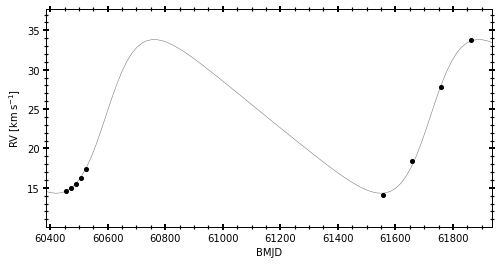

In [22]:
def test_tj(time, rv, err, Pi,Pf,K0=20, max_posterior=1000, error=0.1,chains=2, prior_size=50_000,save=False,MCMC=False):
    plt.rcParams['figure.facecolor']    = 'white'
    
    data           = Table()
    data['bjd']    = time
    data['rv']     = rv
    data['rv_err'] = err

    print('error range: %.2f-%.2f' % (min(err),max(err)))
    
    t = Time(data["bjd"], format="mjd", scale="tcb")
    
    rnd = np.random.default_rng(seed=42)
    
    data = tj.RVData(t=t, rv=data["rv"]*u.km/u.s, rv_err=data["rv_err"]*u.km/u.s)
    
    with pm.Model() as model:
        prior = tj.JokerPrior.default(
                P_min = Pi * u.day, # to use Joker's default log-normal, give P-min, P-max
                P_max = Pf * u.day,
                sigma_K0 = K0 * u.km / u.s,
                sigma_v = 100*u.km/u.s
        )

    prior_samples = prior.sample(size=prior_size, rng=rnd)
    
    joker = tj.TheJoker(prior, rng=rnd)


    print('running joker for posterior samples...')
    joker_samples = joker.rejection_sample(data, prior_samples, 
                                           max_posterior_samples=max_posterior,
                                           return_all_logprobs=True)
    print('# of joker samples returned second round:',len(joker_samples[0]))

    fig, ax = plt.subplots(1, 1, figsize=(8, 4))

    _ = tj.plot_rv_curves(
            joker_samples[0],
            data=data,
            ax=ax,
        )
    plt.show()
#         if save: fig.savefig('../joker_samples/%s_RG%s_%s.png'%(program,obj,DATE),bbox_inches='tight',dpi=100)

    return prior_samples, joker_samples, -999, -999, prior.par_names


t1   = np.concatenate([t0, simulate_time])
rv1  = np.concatenate([rv0, simulate_rv])

rv_err = [0.1]*len(t1)
_, joker_samples, _, _, _ = test_tj(t1, rv1, rv_err, Pi=1, Pf=3000)
#     keep_samples[i] = joker_samples

In [23]:
# good_samples = keep_samples[7]

In [24]:
def replot_data(time, rv, err, samples):
    plt.rcParams['figure.facecolor']    = 'white'
    
    data           = Table()
    data['bjd']    = time
    data['rv']     = rv
    data['rv_err'] = err

    print('error range: %.2f-%.2f' % (min(err),max(err)))
    
    t = Time(data["bjd"], format="mjd", scale="tcb")
    
    rnd = np.random.default_rng(seed=42)
    
    data = tj.RVData(t=t, rv=data["rv"]*u.km/u.s, rv_err=data["rv_err"]*u.km/u.s)
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))

    _ = tj.plot_rv_curves(
            samples[0],
            data=data,
            ax=ax,
        )

# replot_data(t1, rv1, rv_err, keep_samples[7])

333
[60455.31590345 60473.35703503 60489.37269492 60506.08668542
 60526.12898924] [14.58151513 14.97103738 15.48562807 16.29001445 17.34191933]
61991.5
61893.5


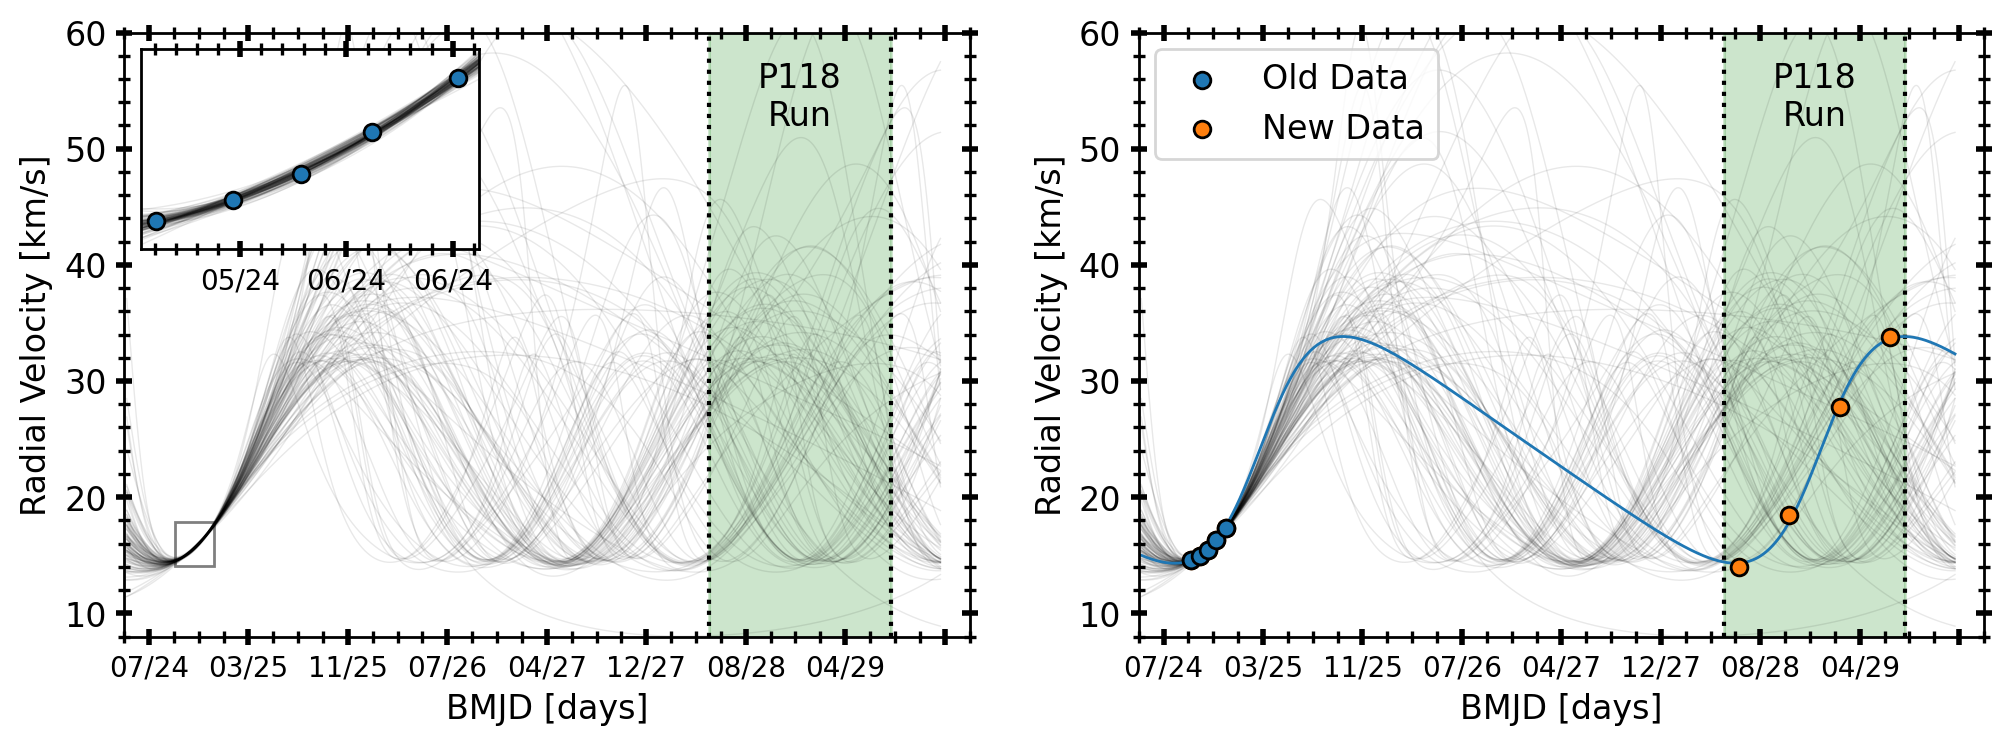

In [134]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def make_plot(program, obj, new_samples, new_time, new_rv, new_rv_err, time=False, rv=False, N=1, ylim=False,xlim=False,n_sample=5):
    
#     if time is False:
    target_time, target_rv, _, _, _ = clean_up(rv_df[(rv_df.RG_id==obj) & (rv_df.program==program)], source='ESPRESSO')
    idx = np.argsort(target_time)
    target_time, target_rv = target_time[idx], target_rv[idx]

    t0 = min(target_time)
    
    data = Table()
    data["bjd"]     = target_time
    data["rv"]      = target_rv
    target_time = Time(data["bjd"], format="jd", scale="tcb")

    fname   = '../joker_samples/%s_%s_joker_%s.hdf5'%(program,obj,version)
    joker_samples = tj.JokerSamples.read(fname)
    print(len(joker_samples))
    fig = plt.figure(figsize=(12,4),dpi=200)
    ax1 = plt.subplot(121)
    ax3 = plt.subplot(122,sharex=ax1,sharey=ax1)
#     ax3 = plt.subplot(133)
    inset_ax = inset_axes(ax1, width="40%", height=1., loc="upper left")

    print(target_time.mjd, target_rv)
    current_time = np.linspace(min(target_time.mjd)-100, max(target_time.mjd)+100, 10000)
    future_time  = np.linspace(p118_start_mjd-2, p118_end_mjd+2, 10000)
    all_time = np.linspace(min(target_time.mjd)-100, p118_end_mjd+100, 10000)
    print(all_time[-1])
    t1 = Time(all_time, format="mjd", scale="tcb")
#     t2 = Time(future_time, format="mjd", scale="tcb")

    n_plot = n_sample
    Q = 4.0  # HACK
    line_alpha = 0.05 + Q / (n_plot + Q)
    
    
    for n_sample in range(n_sample):
        orbit = joker_samples.get_orbit(n_sample).radial_velocity(t1)
    
        ax1.plot(all_time, orbit,c='k',alpha=line_alpha,lw=0.5)
        #ax2.plot(all_time, orbit,c='k',alpha=line_alpha,lw=0.5)
        ax3.plot(all_time, orbit,c='k',alpha=line_alpha,lw=0.5)
        inset_ax.plot(all_time, orbit,c='k',alpha=line_alpha,lw=0.5)
        
    xlim=(60451.77524916038, 60531.11762218476)
    ylim=(14.02943429160872, 17.894000166091878)
    
    inset_ax.scatter(target_time.mjd, target_rv, ec='k',zorder=100, fc='C0')
    plt.xlim(xlim)
    plt.ylim(ylim)
    #plt.xticks([]); 
    plt.yticks([])  # strip ticks, which collide w/ main ax

    # add zoom leaders
    ax1.indicate_inset_zoom(inset_ax, edgecolor="k")
    
    # TICKS - inset
    xticks=inset_ax.get_xticks()
    t = Time(np.array(xticks), format='mjd')
    dt_object = t.datetime
    xlabels = [i.strftime('%m/%y') for i in dt_object]
    inset_ax.set_xticklabels(xlabels,fontsize=10)

    # TICKS - ax1
    xticks=ax1.get_xticks()
    t = Time(np.array(xticks), format='mjd')
    dt_object = t.datetime
    xlabels = [i.strftime('%m/%y') for i in dt_object]
    ax1.set_xticklabels(xlabels)

    # TICKS - ax3
    xticks=ax3.get_xticks()
    t = Time(np.array(xticks), format='mjd')
    dt_object = t.datetime
    xlabels = [i.strftime('%m/%y') for i in dt_object]
    ax3.set_xticklabels(xlabels)

    ytext = 52
    LABEL = 'P118\nRun'
    #ax1.text(p118_start_mjd,ytext, 'P118   Start',ha='center',fontsize=9)
    #ax1.text(p118_end_mjd,ytext, 'P118  End',ha='center',fontsize=9)
    ax1.text((p118_start_mjd+p118_end_mjd)*0.5,ytext, LABEL,ha='center',fontsize=12)
    ax1.axvline(p118_start_mjd,ls='dotted',color='k')
    ax1.axvline(p118_end_mjd,ls='dotted',color='k')
    
    #ax3.text(p118_start_mjd,ytext, 'P118   Start',ha='center',fontsize=9)
    #ax3.text(p118_end_mjd,ytext, 'P118  End',ha='center',fontsize=9)
    ax3.text((p118_start_mjd+p118_end_mjd)*0.5,ytext, LABEL,ha='center',fontsize=12)
    ax3.axvline(p118_start_mjd,ls='dotted',color='k')
    ax3.axvline(p118_end_mjd,ls='dotted',color='k')
    
    ax1.axvspan(p118_start_mjd,p118_end_mjd,color='green', alpha=0.2,zorder=-1000)
    ax3.axvspan(p118_start_mjd,p118_end_mjd,color='green', alpha=0.2,zorder=-1000)
    
    for ax in [ax1,ax3]:
        ax.set_xlabel('BMJD [days]')
        ax.set_ylabel('Radial Velocity [km/s]')
        ax.xaxis.set_tick_params(labelsize=10)
        
    # Last plot
    for i in range(len(new_samples)):
        orbit = new_samples.get_orbit(i).radial_velocity(t1)
        ax3.plot(all_time, orbit,c='C0',alpha=1,lw=1)
        
    ax3.errorbar(new_time, new_rv, yerr=new_rv_err, fmt='o',color='C1',capsize=2,lw=1,zorder=-10)
    ax3.scatter(target_time.mjd, target_rv, ec='k',zorder=100, fc='C0', label='Old Data')
    ax3.scatter(new_time, new_rv, ec='k', fc='C1',zorder=10, label='New Data')
    
    ax3.legend(loc='upper left')
    
    ax1.set_ylim(8,60)
    ax1.set_xlim(60350,62050)
    #ax1.axvspan(p118_start_mjd,p118_end_mjd ,color='green',alpha=0.1,zorder=0)
    print(p118_end_mjd+2)
    
make_plot(113, 23, joker_samples[0], t1, rv1, rv_err, n_sample=100,)
# plt.savefig('../p118_proposal/p118_orbit_plot_%s_N=2.png'%DATE,bbox_inches='tight',dpi=200)


In [26]:
ss

NameError: name 'ss' is not defined

In [ ]:
# save joker samples
save_dir = 'p118_joker_samples_test_joker_1.hdf5'
# joker_samples[0].write(save_dir, overwrite=True)


In [ ]:
ss

In [ ]:
rv precious in harps of red giants, non-neglible have intrinstic scatter due to convective motion, 
monthly cadence will be sufficient will be ale to tease out binarity 

show posteriors before and after with just 6 data points with a different color

* double check what eso means by SNR (per pixel, per resolution, at what wavelength)




In [ ]:

plot_one_star(112, 23, N=20, ylim=(-22,9), xlim=(60345, 60390))  

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
# plt.savefig('../p118_plot_2.png',bbox_inches='tight',dpi=200)
plt.show()



In [ ]:
ss

In [ ]:
plot_tj(rv_df, 23 , 113, N=2)


In [ ]:
plot_tj(rv_df, 23 , 112, N=2)


In [ ]:
def clean_up0(df):
    galah_id = df.sobject_id.values[0]
    dtemp    = comb_df[(comb_df.GALAH_ID==galah_id)]

    time = dtemp['time'].to_numpy()
    rv   = dtemp['rv'].to_numpy()
    err  = dtemp['rv_err'].to_numpy()
    source  = dtemp['source'].to_numpy()
    
    return time, rv, err, source, dtemp


In [ ]:
version = 1
def plot_tj(df, obj,program,N=100):
    fig= plt.figure(dpi=100)
    ax=plt.subplot(111)
    dftemp  = df[(df.RG_id==obj) & (df.program==program)]
    time, rv, rv_err, source, dft = clean_up0(dftemp)
    dft

    idx = np.argsort(time)
    time, rv, rv_err, source = time[idx], rv[idx], rv_err[idx], source[idx]
    time, rv, rv_err, source = time[1:], rv[1:], rv_err[1:], source[1:]
    rv_err                = np.array(rv_err)
    rv_err[(rv_err<0.10)] = 0.10
    print(time)
    fname   = '../joker_samples/%s_%s_joker_%s.hdf5'%(program,obj,version)
    joker_samples = tj.JokerSamples.read(fname)
    print(len(joker_samples),obj, program)

    print('rv1',rv)
    data = Table()
    data['bjd']     = time
    data['rv']      = rv
    data['rv_err']  = rv_err
    data["rv"].unit = u.km / u.s
    data["rv_err"].unit = u.km / u.s
    print(data['bjd'])
    t = Time(data["bjd"], format="jd", scale="tcb")
    
    print('rv2',data['rv'])
    
    an_orbit = joker_samples.get_orbit(1).radial_velocity(t)
    print('an_orbit',an_orbit)
    print('t',t)
    print('t.mjd',t.mjd)
    
    print('\n')

#     print(t)
    new_data = tj.RVData(
        t=t,
        rv=u.Quantity(data["rv"]),
        rv_err=u.Quantity(data["rv_err"]))
    print('rv3',list(new_data.rv.value))
    print(list(new_data.t.value))

    x = tj.plot_rv_curves(joker_samples[:N], data=new_data,ax=ax, add_labels=True)

    for n in range(N):
        sample = joker_samples[n]
        for param in ['P', 'e', 'omega', 'M0', 's', 'K', 'v0']:
            print(param,sample[param][0])
        print('\n')
    print(ax.get_xlim())
    print(ax.get_ylim())
    
#     print(joker_samples[:N][0]['v0'][0].value,joker_samples[:N][0]['e'][0].value,joker_samples[:N][0]['K'][0].value)
    
plot_tj(rv_df, 23 , 113, N=2)



In [ ]:

plot_one_star(113, 23,
              time = [60455.3159034499, 60473.357035030145, 60489.37269491982, 60506.086685420014, 60526.128989240155],
              rv = [14.5815151308206, 14.9710373837021, 15.4856280741578, 16.290014447224, 17.34191932688],
              N=2)#, ylim=(14,18)) 
plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.show()


In [ ]:
plot_tj(rv_df, 23 , 113, N=2)
